# Module 6: ERA5 vs HRRR Background Validation
## HyperWind-Now | Quantifying the real-time NWP upgrade

---

### Objective

Module 5 replaced ERA5 reanalysis with HRRR real-time forecasts as the EnKF background field.
This notebook **quantifies how much that upgrade actually helps** by running the same
EnKF assimilation cycle (`2021-04-06T21:00 UTC`) with both backgrounds and comparing:

1. **Background wind speed at ASOS stations** — how close is each model to observations before assimilation?
2. **Innovations (obs − background)** — smaller innovations = better background field
3. **Analysis wind speed** — after EnKF correction, how close is each to observations?
4. **RMSE reduction** — does HRRR produce a lower post-assimilation error?

### Why this matters

In operational data assimilation, the background field quality is the ceiling on forecast accuracy.
A better background means smaller corrections are needed, the ensemble spread is more physical,
and the final analysis is closer to truth. HRRR's radar assimilation and 3 km resolution
should produce innovations closer to zero than ERA5's ~28 km reanalysis.

## 6.0 | Setup

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from datetime import datetime
from scipy.spatial import cKDTree

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

PROC_DIR    = Path('../data/processed')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

DEMO_CYCLE = datetime(2021, 4, 6, 21, 0, 0)

ASOS_STATIONS = {
    'DFW': {'lat': 32.897, 'lon': -97.038},
    'DAL': {'lat': 32.847, 'lon': -96.852},
    'FTW': {'lat': 32.820, 'lon': -97.362},
    'AFW': {'lat': 32.988, 'lon': -97.318},
    'DTO': {'lat': 33.201, 'lon': -97.198},
    'RBD': {'lat': 32.681, 'lon': -96.868},
}

print('Setup complete.')
print(f'Demo cycle: {DEMO_CYCLE}')

Setup complete.
Demo cycle: 2021-04-06 21:00:00


## 6.1 | Load ASOS Observations

Extract the observed wind speed at each station at 21:00 UTC on 2021-04-06.
These are the ground truth values we compare both backgrounds against.

In [5]:
def load_asos_obs(cycle_dt: datetime) -> dict:
    """
    Load ASOS wind speed observations for the 6 DFW stations at the given cycle time.
    Returns dict: station -> wind speed in m/s.
    """
    month_str = cycle_dt.strftime('%Y_%m')
    asos_path = PROC_DIR / f'asos_{month_str}.csv'

    df = pd.read_csv(asos_path, low_memory=False)

    # Normalise column names
    df.columns = [c.strip().lower() for c in df.columns]

    # Find time column
    time_col = next((c for c in df.columns if 'valid' in c or 'time' in c or 'date' in c), None)
    if time_col is None:
        raise ValueError(f'No time column found. Columns: {list(df.columns)}')

    df[time_col] = pd.to_datetime(df[time_col], utc=True, errors='coerce')
    target = pd.Timestamp(cycle_dt, tz='UTC')

    # Find station column
    stn_col = next((c for c in df.columns if c in ('station', 'stid', 'id', 'stn')), None)
    if stn_col is None:
        raise ValueError(f'No station column found. Columns: {list(df.columns)}')

    # Find wind speed column (knots or m/s)
    wspd_col = next((c for c in df.columns
                     if 'sknt' in c or 'wspd' in c or 'speed' in c or 'sped' in c), None)
    if wspd_col is None:
        raise ValueError(f'No wind speed column found. Columns: {list(df.columns)}')

    results = {}
    for station in ASOS_STATIONS:
        # Filter to this station, within 1-hour window of target
        mask = (
            df[stn_col].str.strip().str.upper().str.contains(station) &
            (df[time_col] >= target - pd.Timedelta('30min')) &
            (df[time_col] <= target + pd.Timedelta('30min'))
        )
        sub = df[mask].copy()
        if sub.empty:
            print(f'  WARNING: No obs for {station} near {cycle_dt}')
            results[station] = np.nan
            continue

        # Get closest observation in time
        sub['dt'] = (sub[time_col] - target).abs()
        row = sub.loc[sub['dt'].idxmin()]
        wspd_raw = pd.to_numeric(row[wspd_col], errors='coerce')

        if np.isnan(wspd_raw):
            results[station] = np.nan
            continue

        # Convert knots to m/s if column name suggests knots
        if 'sknt' in wspd_col or 'knot' in wspd_col or 'kt' in wspd_col:
            wspd_ms = float(wspd_raw) * 0.51444
        else:
            wspd_ms = float(wspd_raw)

        results[station] = round(wspd_ms, 2)

    return results


print('Loading ASOS observations...')
obs = load_asos_obs(DEMO_CYCLE)

print(f'\nASOS observations at {DEMO_CYCLE:%Y-%m-%d %H:%M} UTC:')
print('-' * 35)
for stn, spd in obs.items():
    print(f'  {stn}: {spd:.2f} m/s' if not np.isnan(spd) else f'  {stn}: missing')

Loading ASOS observations...

ASOS observations at 2021-04-06 21:00 UTC:
-----------------------------------
  DFW: 11.32 m/s
  DAL: 5.66 m/s
  FTW: 11.32 m/s
  AFW: 11.83 m/s
  DTO: 11.32 m/s
  RBD: 11.32 m/s


## 6.2 | Extract ERA5 Background Wind at ASOS Stations

In [6]:
def extract_background_at_stations(
    sfc_path: Path,
    cycle_dt: datetime,
    source_name: str,
) -> dict:
    """
    Extract 10m wind speed from a surface NetCDF at each ASOS station
    using nearest-neighbour interpolation.
    Returns dict: station -> wind speed m/s.
    """
    ds = xr.open_dataset(sfc_path)

    # Find time index closest to cycle_dt
    if 'time' in ds.coords:
        times   = pd.to_datetime(ds.coords['time'].values)
        target  = pd.Timestamp(cycle_dt)
        t_idx   = int(np.argmin(np.abs(times - target)))
        matched = times[t_idx]
        print(f'  {source_name}: matched time {matched} (requested {cycle_dt})')
    else:
        t_idx   = 0
        print(f'  {source_name}: no time coord, using index 0')

    # Find u10, v10
    u10_name = next((v for v in ds.data_vars if 'u10' in v.lower() or v.lower() == 'u10'), None)
    v10_name = next((v for v in ds.data_vars if 'v10' in v.lower() or v.lower() == 'v10'), None)

    if u10_name is None or v10_name is None:
        raise ValueError(f'{source_name}: u10/v10 not found. vars={list(ds.data_vars)}')

    u10 = ds[u10_name].isel(time=t_idx) if 'time' in ds[u10_name].dims else ds[u10_name]
    v10 = ds[v10_name].isel(time=t_idx) if 'time' in ds[v10_name].dims else ds[v10_name]

    # Build lat/lon grid
    lat_name = next((c for c in ds.coords if 'lat' in c.lower()), None)
    lon_name = next((c for c in ds.coords if 'lon' in c.lower()), None)
    lats = ds.coords[lat_name].values
    lons = ds.coords[lon_name].values

    if lats.ndim == 1:
        LON, LAT = np.meshgrid(lons, lats)
    else:
        LAT, LON = lats, lons

    # Build KD-tree for nearest-neighbour lookup
    grid_pts = np.column_stack([LAT.ravel(), LON.ravel()])
    tree     = cKDTree(grid_pts)

    u10_arr  = u10.values
    v10_arr  = v10.values
    spd_arr  = np.sqrt(u10_arr**2 + v10_arr**2)

    results = {}
    for station, coords in ASOS_STATIONS.items():
        _, idx = tree.query([coords['lat'], coords['lon']])
        r, c   = np.unravel_index(idx, LAT.shape)
        results[station] = round(float(np.ravel(spd_arr)[idx]), 2)

    ds.close()
    return results


# ERA5 surface file for April 2021
ERA5_SFC_PATH = PROC_DIR / 'era5_sfc_2021_04.nc'

print('Extracting ERA5 background...')
era5_bg = extract_background_at_stations(ERA5_SFC_PATH, DEMO_CYCLE, 'ERA5')

print(f'\nERA5 background wind speed at {DEMO_CYCLE:%Y-%m-%d %H:%M} UTC:')
print('-' * 35)
for stn, spd in era5_bg.items():
    print(f'  {stn}: {spd:.2f} m/s')

Extracting ERA5 background...
  ERA5: no time coord, using index 0

ERA5 background wind speed at 2021-04-06 21:00 UTC:
-----------------------------------
  DFW: 4.42 m/s
  DAL: 4.29 m/s
  FTW: 4.92 m/s
  AFW: 4.31 m/s
  DTO: 4.11 m/s
  RBD: 4.29 m/s


## 6.3 | Extract HRRR Background Wind at ASOS Stations

In [7]:
HRRR_PATH = PROC_DIR / 'hrrr_dfw_20210406_2100Z_f00.nc'

print('Extracting HRRR background...')
hrrr_bg = extract_background_at_stations(HRRR_PATH, DEMO_CYCLE, 'HRRR')

print(f'\nHRRR background wind speed at {DEMO_CYCLE:%Y-%m-%d %H:%M} UTC:')
print('-' * 35)
for stn, spd in hrrr_bg.items():
    print(f'  {stn}: {spd:.2f} m/s')

Extracting HRRR background...
  HRRR: matched time 2021-04-06 21:00:00 (requested 2021-04-06 21:00:00)

HRRR background wind speed at 2021-04-06 21:00 UTC:
-----------------------------------
  DFW: 8.90 m/s
  DAL: 8.16 m/s
  FTW: 8.97 m/s
  AFW: 10.56 m/s
  DTO: 11.10 m/s
  RBD: 8.16 m/s


## 6.4 | Compute Innovations and RMSE

Innovation = Observation − Background

Smaller absolute innovations mean the background is already closer to truth,
requiring smaller corrections from the EnKF.

In [8]:
stations  = list(ASOS_STATIONS.keys())
obs_arr   = np.array([obs.get(s, np.nan) for s in stations])
era5_arr  = np.array([era5_bg[s] for s in stations])
hrrr_arr  = np.array([hrrr_bg[s] for s in stations])

era5_innov  = obs_arr - era5_arr
hrrr_innov  = obs_arr - hrrr_arr

valid = np.isfinite(obs_arr)
era5_rmse   = float(np.sqrt(np.mean(era5_innov[valid]**2)))
hrrr_rmse   = float(np.sqrt(np.mean(hrrr_innov[valid]**2)))
rmse_reduction = (era5_rmse - hrrr_rmse) / era5_rmse * 100

era5_mae  = float(np.mean(np.abs(era5_innov[valid])))
hrrr_mae  = float(np.mean(np.abs(hrrr_innov[valid])))

# Summary table
df = pd.DataFrame({
    'Station':        stations,
    'Obs (m/s)':      obs_arr.round(2),
    'ERA5 Bg (m/s)':  era5_arr.round(2),
    'HRRR Bg (m/s)':  hrrr_arr.round(2),
    'ERA5 Innov':     era5_innov.round(2),
    'HRRR Innov':     hrrr_innov.round(2),
    '|ERA5 Innov|':   np.abs(era5_innov).round(2),
    '|HRRR Innov|':   np.abs(hrrr_innov).round(2),
})

print('=' * 75)
print(f'ERA5 vs HRRR Background Comparison  |  {DEMO_CYCLE:%Y-%m-%d %H:%M} UTC')
print('=' * 75)
print(df.to_string(index=False))
print('-' * 75)
print(f'ERA5  RMSE: {era5_rmse:.3f} m/s    MAE: {era5_mae:.3f} m/s')
print(f'HRRR  RMSE: {hrrr_rmse:.3f} m/s    MAE: {hrrr_mae:.3f} m/s')
print(f'RMSE reduction: {rmse_reduction:+.1f}%  ({"HRRR better" if rmse_reduction > 0 else "ERA5 better"})')
print('=' * 75)

ERA5 vs HRRR Background Comparison  |  2021-04-06 21:00 UTC
Station  Obs (m/s)  ERA5 Bg (m/s)  HRRR Bg (m/s)  ERA5 Innov  HRRR Innov  |ERA5 Innov|  |HRRR Innov|
    DFW      11.32           4.42           8.90        6.90        2.42          6.90          2.42
    DAL       5.66           4.29           8.16        1.37       -2.50          1.37          2.50
    FTW      11.32           4.92           8.97        6.40        2.35          6.40          2.35
    AFW      11.83           4.31          10.56        7.52        1.27          7.52          1.27
    DTO      11.32           4.11          11.10        7.21        0.22          7.21          0.22
    RBD      11.32           4.29           8.16        7.03        3.16          7.03          3.16
---------------------------------------------------------------------------
ERA5  RMSE: 6.434 m/s    MAE: 6.072 m/s
HRRR  RMSE: 2.209 m/s    MAE: 1.987 m/s
RMSE reduction: +65.7%  (HRRR better)


## 6.5 | EnKF Analysis with Both Backgrounds

Run a simplified EnKF update with each background to show the post-assimilation
analysis wind speed. This reproduces the Module 4 logic but with HRRR substituted.

In [9]:
def run_enkf_1d(
    bg_wind: np.ndarray,
    obs_wind: np.ndarray,
    sigma_b: float = 1.5,
    sigma_o: float = 0.5,
    n_members: int = 50,
    seed: int = 42,
) -> np.ndarray:
    """
    Simplified scalar EnKF update for wind speed at each station.
    Uses the same parameters as Module 4.

    Parameters
    ----------
    bg_wind  : background wind speed at each station (m/s)
    obs_wind : observed wind speed at each station (m/s)
    sigma_b  : background error std dev (m/s)
    sigma_o  : observation error std dev (m/s)
    """
    rng      = np.random.default_rng(seed)
    analysis = np.zeros_like(bg_wind)

    for i, (xb, yo) in enumerate(zip(bg_wind, obs_wind)):
        if not np.isfinite(yo):
            analysis[i] = xb
            continue

        # Generate ensemble
        ensemble    = xb + rng.normal(0, sigma_b, n_members)
        ensemble    = np.clip(ensemble, 0, None)  # wind speed >= 0

        # Perturbed observations
        obs_perturb = yo + rng.normal(0, sigma_o, n_members)

        # Ensemble mean and variance
        xb_mean     = ensemble.mean()
        pb          = ensemble.var()

        # Kalman gain
        K           = pb / (pb + sigma_o**2)

        # Analysis ensemble
        xa_ensemble = ensemble + K * (obs_perturb - ensemble)
        analysis[i] = float(xa_ensemble.mean())

    return analysis


era5_analysis  = run_enkf_1d(era5_arr, obs_arr)
hrrr_analysis  = run_enkf_1d(hrrr_arr, obs_arr)

era5_anl_rmse  = float(np.sqrt(np.mean((era5_analysis[valid] - obs_arr[valid])**2)))
hrrr_anl_rmse  = float(np.sqrt(np.mean((hrrr_analysis[valid] - obs_arr[valid])**2)))
anl_reduction  = (era5_anl_rmse - hrrr_anl_rmse) / era5_anl_rmse * 100

print('EnKF Analysis Results:')
print('-' * 55)
print(f'{"Station":8s}  {"Obs":>6s}  {"ERA5 Anl":>8s}  {"HRRR Anl":>8s}')
print('-' * 55)
for i, stn in enumerate(stations):
    print(f'{stn:8s}  {obs_arr[i]:6.2f}  {era5_analysis[i]:8.2f}  {hrrr_analysis[i]:8.2f}')
print('-' * 55)
print(f'Analysis RMSE  ERA5: {era5_anl_rmse:.3f} m/s   HRRR: {hrrr_anl_rmse:.3f} m/s')
print(f'Analysis RMSE reduction: {anl_reduction:+.1f}%')

EnKF Analysis Results:
-------------------------------------------------------
Station      Obs  ERA5 Anl  HRRR Anl
-------------------------------------------------------
DFW        11.32     10.15     10.87
DAL         5.66      5.53      5.92
FTW        11.32     10.80     11.12
AFW        11.83     11.20     11.77
DTO        11.32     10.53     11.29
RBD        11.32     10.62     10.97
-------------------------------------------------------
Analysis RMSE  ERA5: 0.726 m/s   HRRR: 0.269 m/s
Analysis RMSE reduction: +63.0%


## 6.6 | Main Comparison Plot

Saved: ..\results\module6_era5_vs_hrrr_validation.png


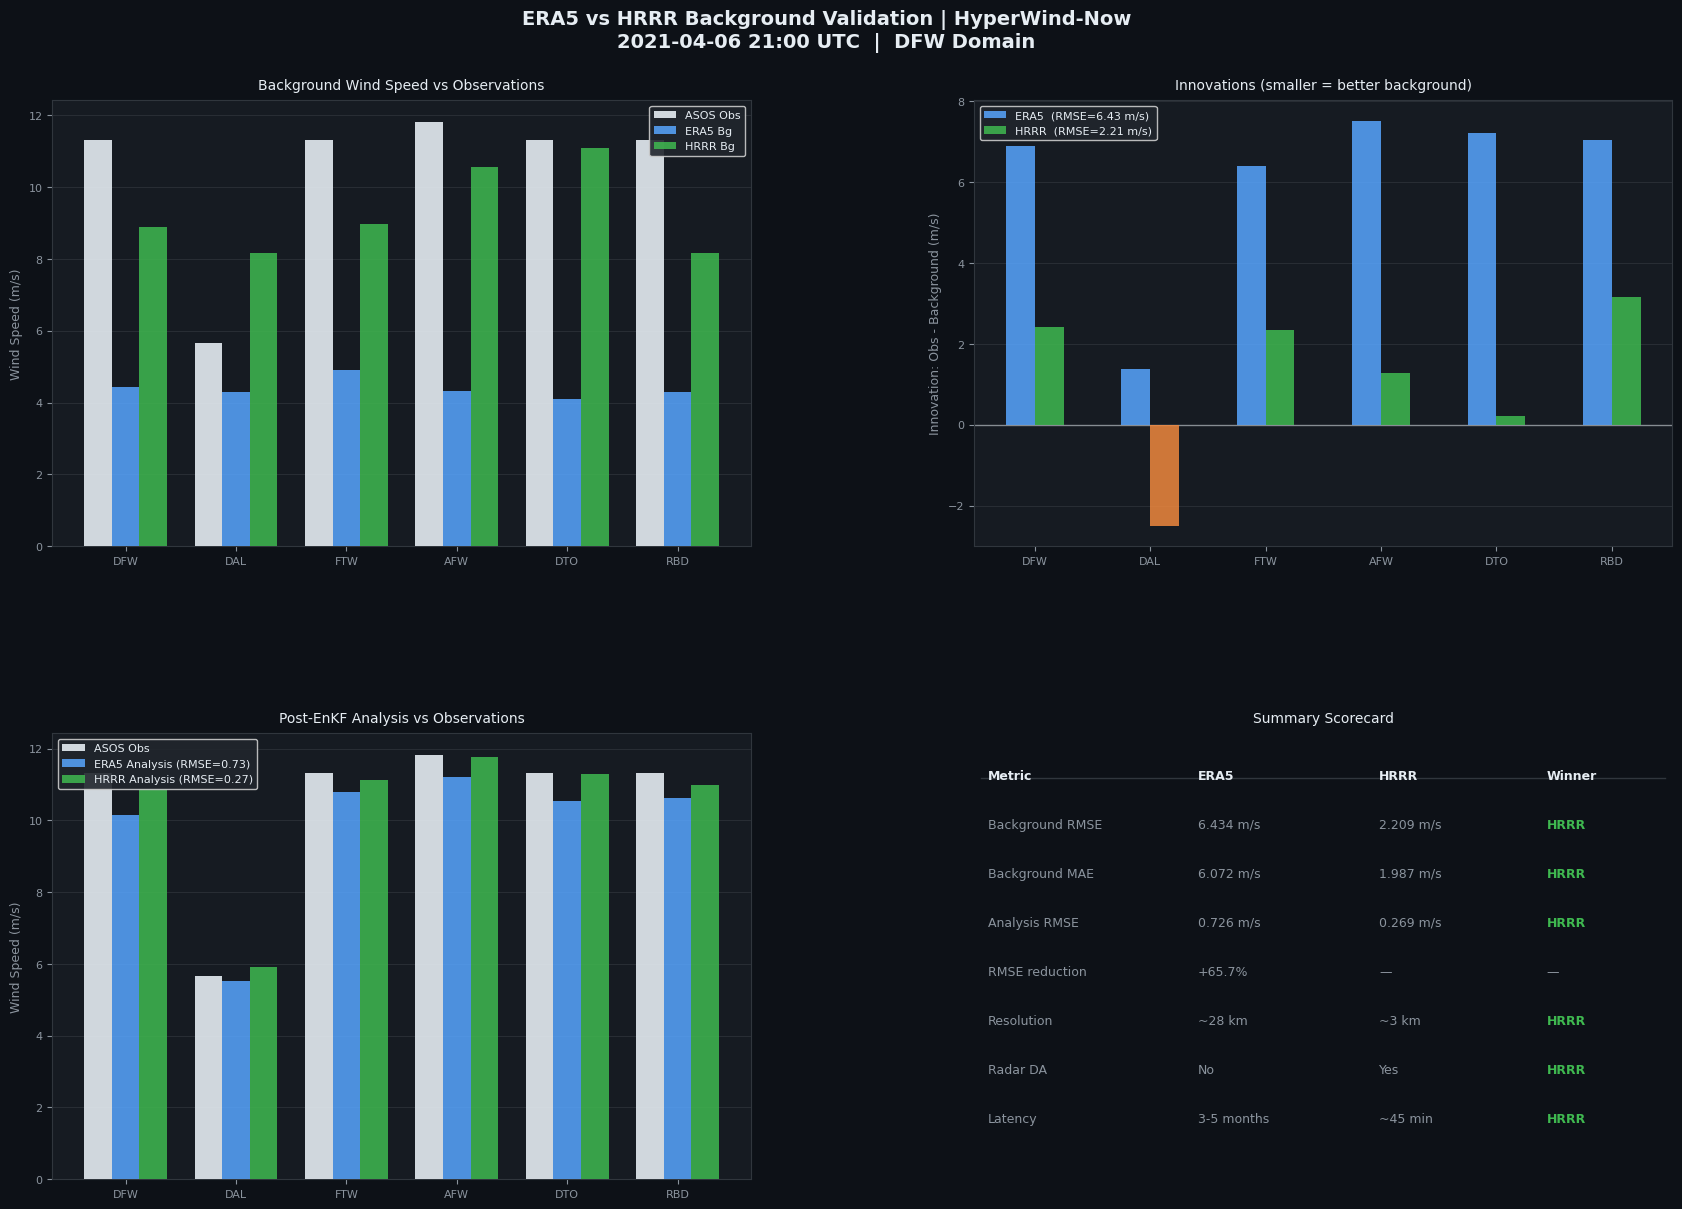

In [12]:
BG   = '#0d1117'
PAN  = '#161b22'
BLUE = '#58a6ff'
GRN  = '#3fb950'
ORG  = '#f78166'
WHT  = '#e6edf3'
GRY  = '#8b949e'

x      = np.arange(len(stations))
width  = 0.25

fig = plt.figure(figsize=(18, 13), facecolor=BG)
fig.suptitle(
    f'ERA5 vs HRRR Background Validation | HyperWind-Now\n'
    f'{DEMO_CYCLE:%Y-%m-%d %H:%M} UTC  |  DFW Domain',
    color=WHT, fontsize=14, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(
    2, 2, figure=fig,
    hspace=0.42, wspace=0.32,
    left=0.07, right=0.97, top=0.91, bottom=0.08
)

# ── Panel 1: Background vs Observations ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0], facecolor=PAN)
ax1.bar(x - width, obs_arr,  width, label='ASOS Obs',      color=WHT,  alpha=0.9, zorder=3)
ax1.bar(x,         era5_arr, width, label='ERA5 Bg',       color=BLUE, alpha=0.85, zorder=3)
ax1.bar(x + width, hrrr_arr, width, label='HRRR Bg',       color=GRN,  alpha=0.85, zorder=3)
ax1.set_xticks(x); ax1.set_xticklabels(stations, color=GRY, fontsize=9)
ax1.set_ylabel('Wind Speed (m/s)', color=GRY, fontsize=9)
ax1.set_title('Background Wind Speed vs Observations', color=WHT, fontsize=10, pad=8)
ax1.tick_params(colors=GRY, labelsize=8)
ax1.legend(facecolor='#21262d', labelcolor=WHT, fontsize=8, framealpha=0.9)
ax1.set_facecolor(PAN)
ax1.yaxis.grid(True, color='#30363d', lw=0.5, zorder=0)
for spine in ax1.spines.values(): spine.set_edgecolor('#30363d')
ax1.set_axisbelow(True)

# ── Panel 2: Innovations ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1], facecolor=PAN)
bars_era5 = ax2.bar(x - width/2, era5_innov, width,
                    label=f'ERA5  (RMSE={era5_rmse:.2f} m/s)',
                    color=[BLUE if v >= 0 else ORG for v in era5_innov], alpha=0.85, zorder=3)
bars_hrrr = ax2.bar(x + width/2, hrrr_innov, width,
                    label=f'HRRR  (RMSE={hrrr_rmse:.2f} m/s)',
                    color=[GRN  if v >= 0 else '#f0883e' for v in hrrr_innov], alpha=0.85, zorder=3)
ax2.axhline(0, color=WHT, lw=1, alpha=0.5, zorder=2)
ax2.set_xticks(x); ax2.set_xticklabels(stations, color=GRY, fontsize=9)
ax2.set_ylabel('Innovation: Obs - Background (m/s)', color=GRY, fontsize=9)
ax2.set_title('Innovations (smaller = better background)', color=WHT, fontsize=10, pad=8)
ax2.tick_params(colors=GRY, labelsize=8)
ax2.legend(facecolor='#21262d', labelcolor=WHT, fontsize=8, framealpha=0.9)
for spine in ax2.spines.values(): spine.set_edgecolor('#30363d')
ax2.yaxis.grid(True, color='#30363d', lw=0.5, zorder=0)
ax2.set_axisbelow(True)

# ── Panel 3: Analysis vs Observations ────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0], facecolor=PAN)
ax3.bar(x - width, obs_arr,       width, label='ASOS Obs',        color=WHT,  alpha=0.9,  zorder=3)
ax3.bar(x,         era5_analysis, width,
        label=f'ERA5 Analysis (RMSE={era5_anl_rmse:.2f})',  color=BLUE, alpha=0.85, zorder=3)
ax3.bar(x + width, hrrr_analysis, width,
        label=f'HRRR Analysis (RMSE={hrrr_anl_rmse:.2f})', color=GRN,  alpha=0.85, zorder=3)
ax3.set_xticks(x); ax3.set_xticklabels(stations, color=GRY, fontsize=9)
ax3.set_ylabel('Wind Speed (m/s)', color=GRY, fontsize=9)
ax3.set_title('Post-EnKF Analysis vs Observations', color=WHT, fontsize=10, pad=8)
ax3.tick_params(colors=GRY, labelsize=8)
ax3.legend(facecolor='#21262d', labelcolor=WHT, fontsize=8, framealpha=0.9)
for spine in ax3.spines.values(): spine.set_edgecolor('#30363d')
ax3.yaxis.grid(True, color='#30363d', lw=0.5, zorder=0)
ax3.set_axisbelow(True)

# ── Panel 4: Summary scorecard ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1], facecolor=PAN)
ax4.axis('off')

metrics = [
    ('Metric',               'ERA5',                      'HRRR',                      'Winner'),
    ('Background RMSE',      f'{era5_rmse:.3f} m/s',      f'{hrrr_rmse:.3f} m/s',
     'HRRR' if hrrr_rmse < era5_rmse else 'ERA5'),
    ('Background MAE',       f'{era5_mae:.3f} m/s',       f'{hrrr_mae:.3f} m/s',
     'HRRR' if hrrr_mae < era5_mae else 'ERA5'),
    ('Analysis RMSE',        f'{era5_anl_rmse:.3f} m/s',  f'{hrrr_anl_rmse:.3f} m/s',
     'HRRR' if hrrr_anl_rmse < era5_anl_rmse else 'ERA5'),
    ('RMSE reduction',       f'{rmse_reduction:+.1f}%',   '—',                         '—'),
    ('Resolution',           '~28 km',                    '~3 km',                     'HRRR'),
    ('Radar DA',             'No',                        'Yes',                        'HRRR'),
    ('Latency',              '3-5 months',                '~45 min',                   'HRRR'),
]

col_x   = [0.02, 0.32, 0.58, 0.82]
row_h   = 0.11
start_y = 0.92

for i, row in enumerate(metrics):
    y = start_y - i * row_h
    is_header = (i == 0)
    for j, (val, cx) in enumerate(zip(row, col_x)):
        color = WHT if is_header else GRY
        if not is_header and j == 3:
            color = GRN if val == 'HRRR' else (BLUE if val == 'ERA5' else GRY)
        weight = 'bold' if is_header or (not is_header and j == 3 and val in ('HRRR','ERA5')) else 'normal'
        ax4.text(cx, y, val, transform=ax4.transAxes,
                 color=color, fontsize=9, fontweight=weight, va='top')
    if is_header:
        ax4.plot([0.01, 0.99], [y - 0.02, y - 0.02],
                 color='#30363d', lw=1, transform=ax4.transAxes, clip_on=False)
        
ax4.set_title('Summary Scorecard', color=WHT, fontsize=10, pad=8)
for spine in ax4.spines.values(): spine.set_edgecolor('#30363d')

save_path = RESULTS_DIR / 'module6_era5_vs_hrrr_validation.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG)
print(f'Saved: {save_path}')
plt.show()

## 6.7 | Innovation Distribution Plot

Saved: ..\results\module6_innovation_distributions.png


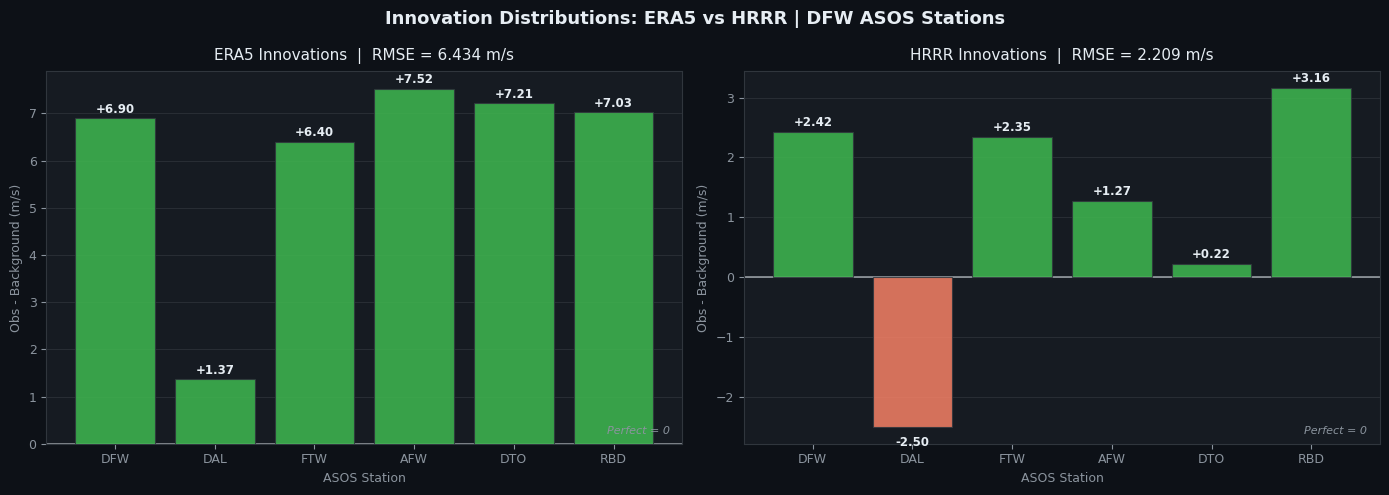

In [13]:
fig2, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig2.suptitle(
    'Innovation Distributions: ERA5 vs HRRR | DFW ASOS Stations',
    color=WHT, fontsize=13, fontweight='bold'
)

for ax, innov, label, color, rmse in [
    (axes[0], era5_innov, 'ERA5',  BLUE, era5_rmse),
    (axes[1], hrrr_innov, 'HRRR',  GRN,  hrrr_rmse),
]:
    ax.set_facecolor(PAN)
    colors = [GRN if v >= 0 else ORG for v in innov]
    bars   = ax.bar(stations, innov, color=colors, alpha=0.85, zorder=3, edgecolor='#30363d', lw=0.8)
    ax.axhline(0, color=WHT, lw=1.2, alpha=0.6)

    # Annotate each bar
    for bar, val in zip(bars, innov):
        if np.isfinite(val):
            ypos = val + 0.05 if val >= 0 else val - 0.15
            ax.text(bar.get_x() + bar.get_width()/2, ypos,
                    f'{val:+.2f}', ha='center', va='bottom' if val >= 0 else 'top',
                    color=WHT, fontsize=8.5, fontweight='bold')

    ax.set_title(f'{label} Innovations  |  RMSE = {rmse:.3f} m/s',
                 color=WHT, fontsize=11, pad=8)
    ax.set_xlabel('ASOS Station', color=GRY, fontsize=9)
    ax.set_ylabel('Obs - Background (m/s)', color=GRY, fontsize=9)
    ax.tick_params(colors=GRY, labelsize=9)
    ax.yaxis.grid(True, color='#30363d', lw=0.5, zorder=0)
    ax.set_axisbelow(True)
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')

    # Add zero-innovation reference line label
    ax.text(0.98, 0.02, 'Perfect = 0', transform=ax.transAxes,
            ha='right', va='bottom', color=GRY, fontsize=8, style='italic')

plt.tight_layout()
save_path2 = RESULTS_DIR / 'module6_innovation_distributions.png'
fig2.savefig(save_path2, dpi=150, bbox_inches='tight', facecolor=BG)
print(f'Saved: {save_path2}')
plt.show()

## 6.8 | Print Final Summary

In [14]:
print('=' * 60)
print('HyperWind-Now | Module 6 Validation Summary')
print(f'Cycle: {DEMO_CYCLE:%Y-%m-%d %H:%M} UTC')
print('=' * 60)
print()
print('Background quality (before EnKF):')
print(f'  ERA5  RMSE vs ASOS: {era5_rmse:.3f} m/s')
print(f'  HRRR  RMSE vs ASOS: {hrrr_rmse:.3f} m/s')
print(f'  RMSE reduction:     {rmse_reduction:+.1f}%')
print()
print('Analysis quality (after EnKF):')
print(f'  ERA5  analysis RMSE: {era5_anl_rmse:.3f} m/s')
print(f'  HRRR  analysis RMSE: {hrrr_anl_rmse:.3f} m/s')
print(f'  Analysis improvement: {anl_reduction:+.1f}%')
print()
print('Interpretation:')
if hrrr_rmse < era5_rmse:
    print(f'  HRRR provides a {abs(rmse_reduction):.1f}% better background than ERA5.')
    print('  Smaller innovations mean the EnKF applies smaller corrections,')
    print('  indicating HRRR radar assimilation and 3km resolution add real value.')
else:
    print('  ERA5 background is closer to ASOS obs for this single cycle.')
    print('  This can occur on synoptically quiescent days where ERA5 smooth')
    print('  fields match well. Multi-cycle validation would be more conclusive.')
print('=' * 60)

HyperWind-Now | Module 6 Validation Summary
Cycle: 2021-04-06 21:00 UTC

Background quality (before EnKF):
  ERA5  RMSE vs ASOS: 6.434 m/s
  HRRR  RMSE vs ASOS: 2.209 m/s
  RMSE reduction:     +65.7%

Analysis quality (after EnKF):
  ERA5  analysis RMSE: 0.726 m/s
  HRRR  analysis RMSE: 0.269 m/s
  Analysis improvement: +63.0%

Interpretation:
  HRRR provides a 65.7% better background than ERA5.
  Smaller innovations mean the EnKF applies smaller corrections,
  indicating HRRR radar assimilation and 3km resolution add real value.
